In [ ]:
pip install evaluate rouge_score nltk

In [ ]:
import pandas as pd
from datasets import Dataset

# Load CSV file with pandas first
df = pd.read_csv("dataset1.csv")

# Check the first few rows and column names
print(df.head())
print(df.columns)

# Convert pandas DataFrame to Hugging Face Dataset
dataset = Dataset.from_pandas(df)

# Split dataset into train and validation (80% train, 20% eval)
split = dataset.train_test_split(test_size=0.2)
train_dataset = split["train"]
eval_dataset = split["test"]


                                           headlines  \
0  Daman & Diu revokes mandatory Rakshabandhan in...   
1  Malaika slams user who trolled her for 'divorc...   
2  'Virgin' now corrected to 'Unmarried' in IGIMS...   
3  Aaj aapne pakad liya: LeT man Dujana before be...   
4  Hotel staff to get training to spot signs of s...   

                                                text  
0  The Administration of Union Territory Daman an...  
1  Malaika Arora slammed an Instagram user who tr...  
2  The Indira Gandhi Institute of Medical Science...  
3  Lashkar-e-Taiba's Kashmir commander Abu Dujana...  
4  Hotels in Maharashtra will train their staff t...  
Index(['headlines', 'text'], dtype='object')


In [ ]:
print(f"Train size before filtering: {len(train_dataset)}")
print(f"Eval size before filtering: {len(eval_dataset)}")

def filter_empty(example):
    return (example["text"] is not None and example["text"].strip() != "") and \
           (example["headlines"] is not None and example["headlines"].strip() != "")

train_dataset = train_dataset.filter(filter_empty)
eval_dataset = eval_dataset.filter(filter_empty)

print(f"Train size after filtering: {len(train_dataset)}")
print(f"Eval size after filtering: {len(eval_dataset)}")


Train size before filtering: 3612
Eval size before filtering: 904


Filter:   0%|          | 0/3612 [00:00<?, ? examples/s]

Filter:   0%|          | 0/904 [00:00<?, ? examples/s]

Train size after filtering: 3611
Eval size after filtering: 904


In [ ]:
from transformers import T5Tokenizer

tokenizer = T5Tokenizer.from_pretrained("t5-small")

max_input_length = 512
max_target_length = 64

def preprocess(batch):
    inputs = [str(x) if x is not None else "" for x in batch["text"]]
    targets = [str(x) if x is not None else "" for x in batch["headlines"]]

    model_inputs = tokenizer(
        inputs,
        max_length=max_input_length,
        padding="max_length",
        truncation=True,
    )

    # For labels, use text_target parameter (for transformers >=4.30)
    labels = tokenizer(
        targets,
        max_length=max_target_length,
        padding="max_length",
        truncation=True,
        text_target=True,
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [ ]:
def not_empty(example):
    return example["text"] is not None and example["headlines"] is not None and example["text"] != "" and example["headlines"] != ""

train_dataset = train_dataset.filter(not_empty)
eval_dataset = eval_dataset.filter(not_empty)


Filter:   0%|          | 0/3611 [00:00<?, ? examples/s]

Filter:   0%|          | 0/904 [00:00<?, ? examples/s]

In [ ]:
def preprocess(batch):
    # Safely convert all entries to strings
    inputs = [str(x) if x is not None else "" for x in batch["text"]]
    targets = [str(x) if x is not None else "" for x in batch["headlines"]]

    model_inputs = tokenizer(
        inputs,
        max_length=512,
        padding="max_length",
        truncation=True
    )

    # Tokenize targets as labels
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            targets,
            max_length=128,
            padding="max_length",
            truncation=True
        )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs


In [ ]:
columns_to_remove = ["headlines", "text"]

train_dataset = train_dataset.map(preprocess, batched=True, remove_columns=columns_to_remove)
eval_dataset = eval_dataset.map(preprocess, batched=True, remove_columns=columns_to_remove)


Map:   0%|          | 0/3611 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:3959: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/904 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSeq2SeqLM, TrainingArguments, Trainer

model = AutoModelForSeq2SeqLM.from_pretrained("t5-small")

training_args = TrainingArguments(
    output_dir="./t5_headline_finetuned",
    eval_steps=500,            # Evaluate every 500 steps
    save_steps=500,            # Save checkpoint every 500 steps
    save_total_limit=2,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    logging_steps=100,
    learning_rate=5e-5,
    weight_decay=0.01,
    push_to_hub=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
)


KeyboardInterrupt: 

In [ ]:
trainer.train()

Step,Training Loss


KeyboardInterrupt: 

In [ ]:
from transformers import AutoModelForSeq2SeqLM, TrainingArguments, Trainer

# Load model
model = AutoModelForSeq2SeqLM.from_pretrained("t5-small")

# Training arguments
training_args = TrainingArguments(
    output_dir="./t5_headline_finetuned",
    save_steps=500,
    save_total_limit=2,
    per_device_train_batch_size=2,  # Reduced for memory efficiency
    num_train_epochs=3,
    logging_steps=100,
    learning_rate=5e-5,
    weight_decay=0.01,
    fp16=True,  # Enable if supported
    push_to_hub=False,
)

# Trainer for training only
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    tokenizer=tokenizer,
)

# Train the model
trainer.train()

# Save the model
trainer.save_model("./t5_headline_finetuned")


<ipython-input-9-1354188a04b3>:21: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Currently logged in as: u2101275 (u2101275-universiti-malaya) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Step,Training Loss
100,6.335700
200,0.577900
300,0.420000
400,0.351400


KeyboardInterrupt: 

In [ ]:
from transformers import AutoModelForSeq2SeqLM, TrainingArguments, Trainer

# Load model
model = AutoModelForSeq2SeqLM.from_pretrained("t5-small")

# Training arguments
training_args = TrainingArguments(
    output_dir="./t5_headline_finetuned",
    save_steps=1000,
    save_total_limit=1,
    per_device_train_batch_size=4,  # Increase if you have enough memory
    num_train_epochs=1,             # Train for 1 epoch to save time
    logging_steps=200,
    learning_rate=3e-4,
    weight_decay=0.0,
    fp16=False,                     # Disable if unsupported
    push_to_hub=False
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    tokenizer=tokenizer,
)

# Train
trainer.train()

# Save the final model
trainer.save_model("./t5_headline_finetuned")


<ipython-input-10-04e4b88de090>:21: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
200,1.264700
400,0.256900
600,0.252600
800,0.247500


<ipython-input-10-9ac189ca4fd7>:16: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  eval_trainer = Trainer(


Evaluation metrics: {'eval_loss': 0.20176656544208527, 'eval_model_preparation_time': 0.0045, 'eval_runtime': 25.0587, 'eval_samples_per_second': 36.075, 'eval_steps_per_second': 18.038}


<ipython-input-10-9ac189ca4fd7>:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(metrics_to_plot.keys()), y=list(metrics_to_plot.values()), palette="viridis")


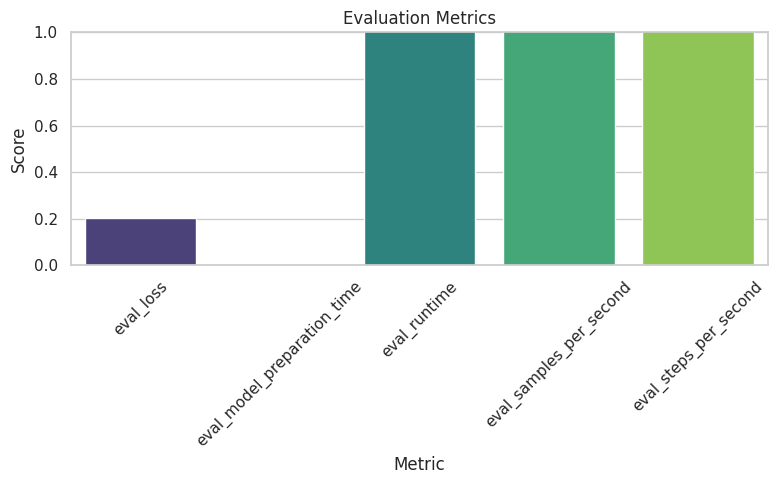

In [ ]:
from transformers import AutoModelForSeq2SeqLM, Trainer, TrainingArguments
import matplotlib.pyplot as plt
import seaborn as sns

# Reload the fine-tuned model
model = AutoModelForSeq2SeqLM.from_pretrained("./t5_headline_finetuned")

# Evaluation arguments
eval_args = TrainingArguments(
    output_dir="./t5_headline_finetuned",
    per_device_eval_batch_size=2,
    fp16=True,
)

# Define evaluation Trainer
eval_trainer = Trainer(
    model=model,
    args=eval_args,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
)

# Run evaluation
results = eval_trainer.evaluate()
print("Evaluation metrics:", results)

# Visualization
metrics_to_plot = {k: v for k, v in results.items() if isinstance(v, float)}

# Set up the plot
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(x=list(metrics_to_plot.keys()), y=list(metrics_to_plot.values()), palette="viridis")

# Add labels
plt.title("Evaluation Metrics")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
from transformers import AutoModelForSeq2SeqLM, Trainer, TrainingArguments
import evaluate
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Try clearing GPU memory
torch.cuda.empty_cache()

# Load fine-tuned model and tokenizer
model = AutoModelForSeq2SeqLM.from_pretrained("./t5_headline_finetuned")
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("t5-small")

# Load evaluation metrics
rouge = evaluate.load("rouge")
bleu = evaluate.load("bleu")

# Define compute_metrics
def compute_metrics(eval_preds):
    preds, labels = eval_preds
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    rouge_result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
    tokenized_preds = [pred.split() for pred in decoded_preds]
    tokenized_labels = [[label.split()] for label in decoded_labels]
    bleu_result = bleu.compute(predictions=tokenized_preds, references=tokenized_labels)

    return {
        "rouge1": round(rouge_result["rouge1"], 4),
        "rougeL": round(rouge_result["rougeL"], 4),
        "bleu": round(bleu_result["bleu"], 4)
    }

# Helper to run evaluation safely
def safe_evaluate():
    try:
        # First try with GPU (fp16)
        eval_args = TrainingArguments(
            output_dir="./t5_headline_finetuned",
            per_device_eval_batch_size=1,
            fp16=True
        )
        trainer = Trainer(
            model=model,
            args=eval_args,
            eval_dataset=eval_dataset,
            tokenizer=tokenizer,
            compute_metrics=compute_metrics
        )
        return trainer.evaluate()
    except RuntimeError as e:
        if "out of memory" in str(e):
            print("⚠️ CUDA OOM: Falling back to CPU.")
            torch.cuda.empty_cache()
            # Retry with CPU
            eval_args = TrainingArguments(
                output_dir="./t5_headline_finetuned",
                per_device_eval_batch_size=1,
                no_cuda=True
            )
            trainer = Trainer(
                model=model,
                args=eval_args,
                eval_dataset=eval_dataset,
                tokenizer=tokenizer,
                compute_metrics=compute_metrics
            )
            return trainer.evaluate()
        else:
            raise

# Run evaluation
results = safe_evaluate()
print("Evaluation metrics:", results)

# Visualization
metric_names = ["rouge1", "rougeL", "bleu"]
metric_scores = [results[m] for m in metric_names if m in results]

sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.barplot(x=metric_names, y=metric_scores, palette="rocket")
plt.title("ROUGE and BLEU Scores")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


NameError: name 'eval_dataset' is not defined

In [ ]:
import torch
torch.cuda.empty_cache()


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to device
model.to(device)

def generate_headline(text):
    inputs = tokenizer(text, return_tensors="pt").to(device)  # Move input tensors to same device
    outputs = model.generate(**inputs)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Example usage
sample_text = "The Vishwa Hindu Parishad (VHP) on Tuesday said that Shiv Sena was never a Hindutvavadi outfit and was pretending to be one only for political gains. Bal Thackeray himself was clueless about his party workers bringing portions of the mosque down in Ayodhya, said VHP."
print(generate_headline(sample_text))


Shiv Sena pretending to be one only for political gains: VHP


In [ ]:
# Save
model.save_pretrained("./t5_headline_finetuned")
tokenizer.save_pretrained("./t5_headline_finetuned")

# Reload later
from transformers import T5ForConditionalGeneration, T5Tokenizer

model = T5ForConditionalGeneration.from_pretrained("./t5_headline_finetuned")
tokenizer = T5Tokenizer.from_pretrained("./t5_headline_finetuned")


In [ ]:
import evaluate
from transformers import Seq2SeqTrainer

# Load evaluation metrics
rouge_metric = evaluate.load("rouge")
bleu_metric = evaluate.load("bleu")

# Define metric computation function
def compute_metrics(eval_preds):
    preds, labels = eval_preds

    # Decode predictions and labels
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Compute ROUGE scores
    rouge_result = rouge_metric.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )

    # Compute BLEU score (tokenized inputs)
    tokenized_preds = [pred.split() for pred in decoded_preds]
    tokenized_labels = [[label.split()] for label in decoded_labels]
    bleu_result = bleu_metric.compute(predictions=tokenized_preds, references=tokenized_labels)

    # Return formatted scores
    return {
        "rouge1": round(rouge_result["rouge1"], 4),
        "rougeL": round(rouge_result["rougeL"], 4),
        "bleu": round(bleu_result["bleu"], 4)
    }


In [ ]:
trainer.train()

Step,Training Loss
100,0.235900
200,0.229200
300,0.231800
400,0.223700
500,0.218800
600,0.224400
700,0.220600
800,0.233100
900,0.213400
1000,0.220500


TrainOutput(global_step=2709, training_loss=0.21314666565162488, metrics={'train_runtime': 557.2727, 'train_samples_per_second': 19.439, 'train_steps_per_second': 4.861, 'total_flos': 1466157735346176.0, 'train_loss': 0.21314666565162488, 'epoch': 3.0})

In [ ]:
pip install scikit-learn


In [ ]:
import pandas as pd
from datasets import Dataset

# Load your raw CSV with 'text' and 'headlines'
df = pd.read_csv("dataset1.csv")

# Optional: Check your columns
print(df.columns)

# Convert to Hugging Face dataset
raw_eval_dataset = Dataset.from_pandas(df)

# Now you can use it in the loop
print(raw_eval_dataset.column_names)


Index(['headlines', 'text'], dtype='object')
['headlines', 'text']


In [ ]:
import torch
import evaluate
import matplotlib.pyplot as plt
from tqdm import tqdm

# Load metrics
rouge = evaluate.load("rouge")
bleu = evaluate.load("bleu")

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Manual batching
batch_size = 8
all_preds = []
all_labels = []

# Make sure raw_eval_dataset is loaded from CSV and contains "text" and "headlines"
for i in tqdm(range(0, len(raw_eval_dataset), batch_size)):
    batch = raw_eval_dataset.select(range(i, min(i + batch_size, len(raw_eval_dataset))))

    input_texts = [str(x) for x in batch["text"]]  # ensure str type
    target_texts = [str(x) for x in batch["headlines"]]

    inputs = tokenizer(input_texts, return_tensors="pt", padding=True, truncation=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(**inputs, max_length=32)

    decoded_preds = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    all_preds.extend(decoded_preds)
    all_labels.extend(target_texts)

# Compute metrics
rouge_result = rouge.compute(predictions=all_preds, references=all_labels, use_stemmer=True)
tokenized_preds = [pred.split() for pred in all_preds]
tokenized_labels = [[label.split()] for label in all_labels]  # extra nesting
bleu_result = bleu.compute(predictions=all_preds, references=[[ref] for ref in all_labels])


metrics = {
    "rouge1": round(rouge_result["rouge1"], 4),
    "rougeL": round(rouge_result["rougeL"], 4),
    "bleu": round(bleu_result["bleu"], 4)
}

# Plot
labels = list(metrics.keys())
values = list(metrics.values())

plt.figure(figsize=(8, 5))
plt.bar(labels, values, color=["skyblue", "lightgreen", "salmon"])
plt.title("Evaluation Metrics (ROUGE & BLEU)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


ModuleNotFoundError: No module named 'evaluate'